Best Parameters: {'max_depth': 5, 'n_estimators': 200}
Regression Results
RMSE: 7.092931193003817
R2: 0.7379387537441102

Classification Results
              precision    recall  f1-score   support

        Long       0.78      0.71      0.75        70
      Medium       0.51      0.55      0.53        74
       Short       0.64      0.64      0.64        56

    accuracy                           0.64       200
   macro avg       0.65      0.64      0.64       200
weighted avg       0.64      0.64      0.64       200



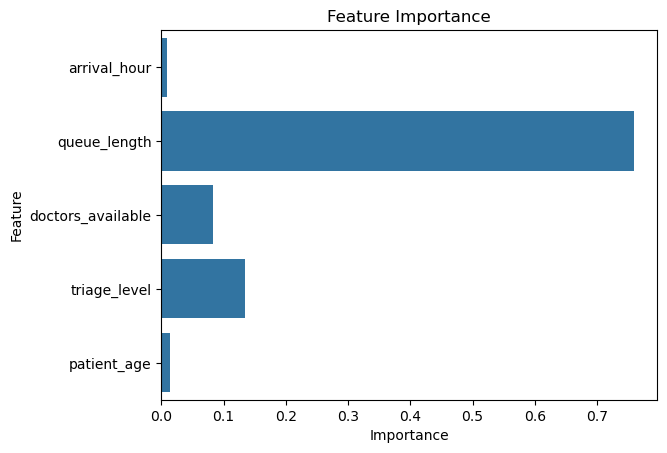

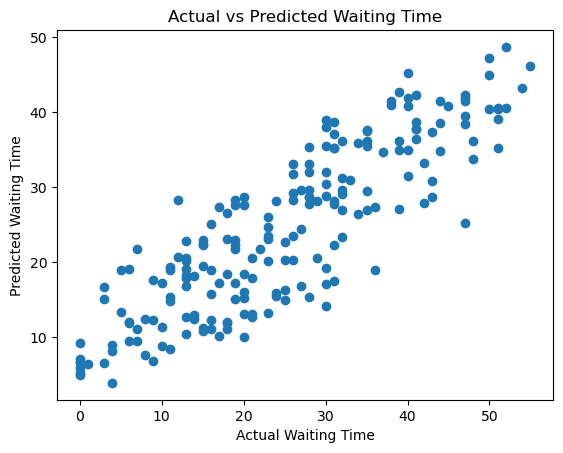

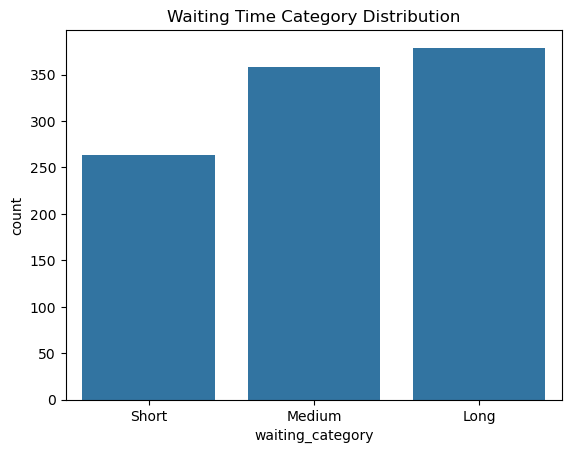

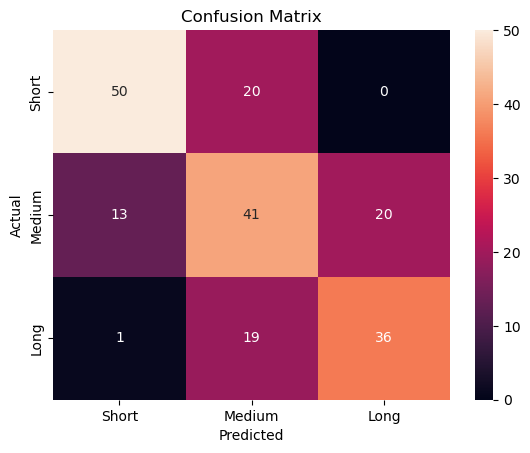

Models saved successfully


In [6]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

# ------------------
# Load Data
# ------------------

data = pd.read_excel("data/hospital_waiting_data.xlsx")

# ------------------
# Create Classification Label
# ------------------

def waiting_category(time):
    if time <= 15:
        return "Short"
    elif time <= 30:
        return "Medium"
    else:
        return "Long"

data["waiting_category"] = data["waiting_time"].apply(waiting_category)

# ------------------
# Features
# ------------------

features = [
    "arrival_hour",
    "queue_length",
    "doctors_available",
    "triage_level",
    "patient_age"
]

X = data[features]

y_reg = data["waiting_time"]
y_cls = data["waiting_category"]

# ------------------
# Train Test Split
# ------------------

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_cls_train, y_cls_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

# ------------------
# Hyperparameter Tuning
# ------------------

param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[None,5,10]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=2
)

grid.fit(X_train, y_reg_train)

print("Best Parameters:", grid.best_params_)

reg_model = grid.best_estimator_

# ------------------
# Train Classification Model
# ------------------

cls_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

cls_model.fit(X_train, y_cls_train)

# ------------------
# Regression Evaluation
# ------------------

reg_pred = reg_model.predict(X_test)

mse = mean_squared_error(y_reg_test, reg_pred)
rmse = np.sqrt(mse)

print("Regression Results")
print("RMSE:", rmse)
print("R2:", r2_score(y_reg_test, reg_pred))

# ------------------
# Classification Evaluation
# ------------------

cls_pred = cls_model.predict(X_test)

print("\nClassification Results")
print(classification_report(y_cls_test, cls_pred))

# ------------------
# Feature Importance Graph
# ------------------

importances = reg_model.feature_importances_

plt.figure()
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# ------------------
# Actual vs Predicted Graph
# ------------------

plt.figure()
plt.scatter(y_reg_test, reg_pred)
plt.xlabel("Actual Waiting Time")
plt.ylabel("Predicted Waiting Time")
plt.title("Actual vs Predicted Waiting Time")
plt.show()

# ------------------
# Waiting Category Distribution
# ------------------

plt.figure()
sns.countplot(x=data["waiting_category"])
plt.title("Waiting Time Category Distribution")
plt.show()

# ------------------
# Confusion Matrix
# ------------------

cm = confusion_matrix(y_cls_test, cls_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Short","Medium","Long"],
            yticklabels=["Short","Medium","Long"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------
# Save Models
# ------------------

joblib.dump(reg_model, "models/regression_model.pkl")
joblib.dump(cls_model, "models/classification_model.pkl")

print("Models saved successfully")